In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier # O LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Fairness
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference

# Explicabilidad
import shap
import lime
#import lime.lime_tabular
import matplotlib.pyplot as plt

In [4]:
def load_and_clean_compas(path):
    """
    Carga del dataset Compas y limpieza base.
    """
    df = pd.read_csv(path)
    
    # Filtrado por calidad de datos
    df = df[
        (df['days_b_screening_arrest'] <= 30) & 
        (df['days_b_screening_arrest'] >= -30) &
        (df['is_recid'] != -1) &
        (df['c_charge_degree'] != 'O') # 'O' es ordinario/menor
    ]
    
    # Selección de variables relevantes (Features) y Target
    features = [
        'sex', 'age', 'age_cat', 'race', 
        'juv_fel_count', 'juv_misd_count', 'juv_other_count', 
        'priors_count', 'c_charge_degree'
    ]
    target = 'two_year_recid'
    
    return df[features], df[target]

#### **4.1 - Preprocesamiento**

In [5]:
X, y = load_and_clean_compas('./dataset/compas-scores-two-years.csv')

# Estrategia de estratificación (Target + Raza)
# Esto asegura que el sesgo racial se pueda medir con la misma precisión en train y test
stratify_cols = y.astype(str) + X['race'].astype(str)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30,        
    random_state=42, 
    stratify=stratify_cols # Estratificación multidimensional
)

# Identificación de tipos de columnas
numeric_features = ['age', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count']
categorical_features = ['sex', 'age_cat', 'race', 'c_charge_degree']

# Creación de Transformers
# Para numéricas: Imputación por mediana + Escalado estándar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Para categóricas: Imputación por el más frecuente + OneHot (evitando multicolinealidad)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Ensamblaje del ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

#### **4.2 - Modelo baseline**

##### Construcción del Pipeline

In [6]:
def entrenar_modelo(model, preprocessor, X_train, y_train):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    return pipeline

Modelo XGBoost

In [7]:
pipeline_xgb = entrenar_modelo(XGBClassifier(n_estimators=100, random_state=42), preprocessor, X_train, y_train)

Random Forest

In [11]:
pipeline_rf = entrenar_modelo(RandomForestClassifier(n_estimators=100, random_state=42), preprocessor, X_train, y_train)

##### Rendimiento del modelo

In [13]:
def evaluar_rendimiento(pipeline, X_test, y_test):
    """Calcula las métricas de rendimiento estándar del modelo."""
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    }
    
    print("--- Rendimiento del Modelo ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))
    
    return metrics

In [14]:
metricas = evaluar_rendimiento(pipeline_xgb, X_test, y_test)

--- Rendimiento del Modelo ---
Accuracy: 0.6555
AUC: 0.7014

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.66      0.75      0.70      1009
           1       0.64      0.55      0.59       843

    accuracy                           0.66      1852
   macro avg       0.65      0.65      0.65      1852
weighted avg       0.65      0.66      0.65      1852



In [15]:
metricas = evaluar_rendimiento(pipeline_rf, X_test, y_test)

--- Rendimiento del Modelo ---
Accuracy: 0.6199
AUC: 0.6640

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.65      0.65      0.65      1009
           1       0.58      0.59      0.58       843

    accuracy                           0.62      1852
   macro avg       0.62      0.62      0.62      1852
weighted avg       0.62      0.62      0.62      1852



##### Evaluación de Equidad (Fairness)

In [8]:
def evaluar_equidad(pipeline, X_test, y_test, grupo_sensible):
    """
    Evalúa si el modelo es 'justo' comparando predicciones entre grupos.
    grupo_sensible: Columna del dataset que representa la raza (atributo A).
    """
    y_pred = pipeline.predict(X_test)
    
    # Definimos las métricas a monitorizar por grupo
    metrics_dict = {
        'selection_rate': selection_rate, # Probabilidad de predecir reincidencia
        'accuracy': accuracy_score
    }
    
    mf = MetricFrame(
        metrics=metrics_dict,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=grupo_sensible
    )
    
    dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=grupo_sensible)
    
    print("--- Métricas de Equidad ---")
    print(f"Demographic Parity Difference: {dp_diff:.4f}")
    print("\nDesglose por grupo:\n", mf.by_group)
    
    return mf

In [9]:
grupo_sensible = X_test["race"]  # o la columna sensible que uses
mf = evaluar_equidad(pipeline, X_test, y_test, grupo_sensible)

--- Métricas de Equidad ---
Demographic Parity Difference: 0.4937

Desglose por grupo:
                   selection_rate  accuracy
race                                      
African-American        0.493697  0.651261
Asian                   0.222222  0.777778
Caucasian               0.256735  0.659271
Hispanic                0.398693  0.647059
Native American         0.000000  0.500000
Other                   0.233010  0.679612


##### Explicabilidad con SHAP

In [16]:
def shap_global(pipeline, X_test):

    model = pipeline.named_steps["classifier"]
    preprocessor = pipeline.named_steps["preprocessor"]

    X_transformed = preprocessor.transform(X_test)

    feature_names = preprocessor.get_feature_names_out()

    X_transformed = pd.DataFrame(
        X_transformed,
        columns=feature_names,
        index=X_test.index
    )

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_transformed)

    shap.summary_plot(
        shap_values,
        X_transformed
    )

    return explainer, shap_values, X_transformed, feature_names

SHAP global xgboost

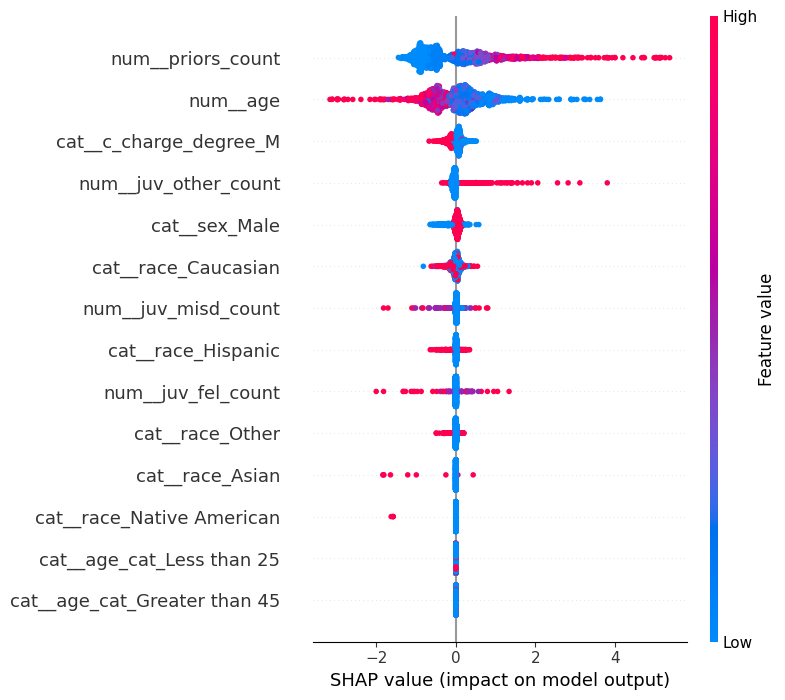

In [18]:
_ = shap_global(pipeline_xgb, X_test)

SHAP global random forest

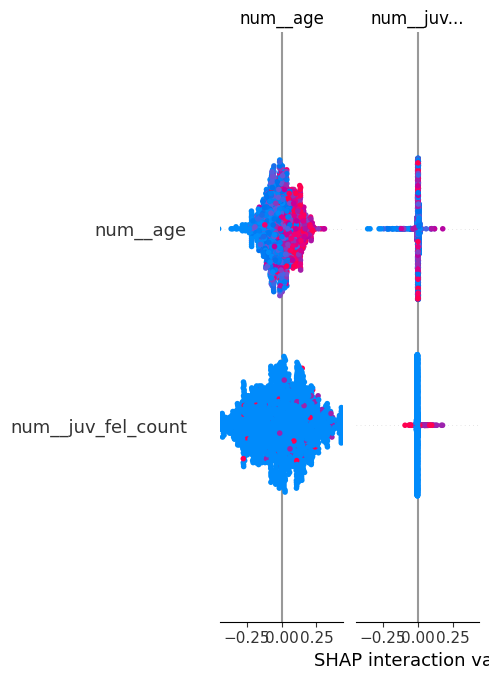

In [19]:
_ = shap_global(pipeline_rf, X_test)

#### **4.3 - Tratamiento de la problemática 1: Fairness**

#### **4.4 - Tratamiento de la problemática 2: Explainability**

SHAP LOCAL

In [20]:
def shap_local(explainer, shap_values, X_transformed, feature_names, idx=0):

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_transformed.iloc[idx],
            feature_names=feature_names
        )
    )

SHAP local XGBoost

SHAP local Random Forest

LIME

In [ ]:
import lime
#import lime.lime_tabular
import matplotlib.pyplot as plt

Clase real: 0
Predicción del modelo: 0
Probabilidad de reincidencia: 0.144


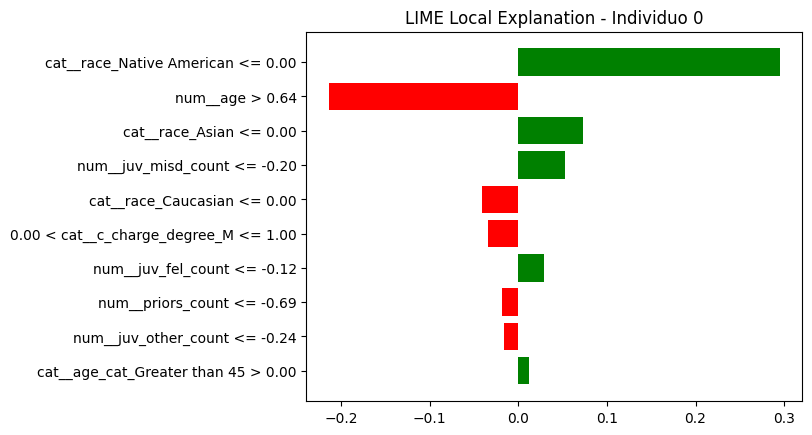

In [ ]:
def lime_local(model, X_transformed, feature_names, idx=0):

    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=np.array(X_transformed),
        feature_names=feature_names,
        class_names=['No Recid', 'Recid'],
        mode='classification'
    )

    lime_exp = lime_explainer.explain_instance(
        X_transformed.iloc[idx].values,
        model.predict_proba,
        num_features=10
    )

    lime_exp.as_pyplot_figure()

    plt.show()

SHAP con dependencias entre variables

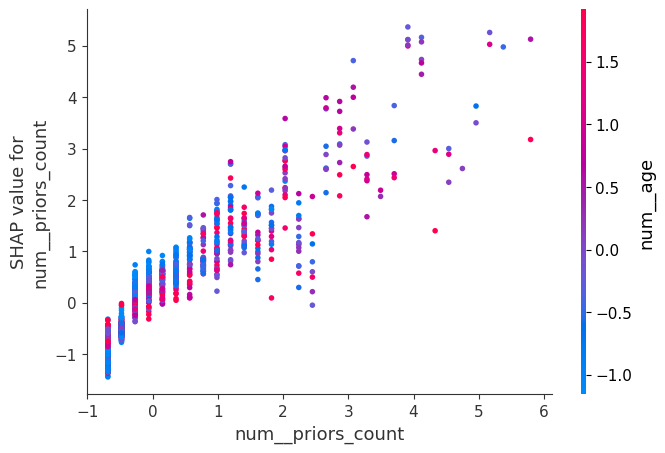

In [ ]:
def shap_dependence( feature, shap_values, X_transformed, feature_names, interaction=None):

    shap.dependence_plot(
        feature,
        shap_values,
        X_transformed,
        feature_names=feature_names,
        interaction_index=interaction
    )